# **MÓDULO 17 - Projeto de Credit Score - Parte 1 - Processamento dos dados**


Essa é a primeira etapa do processo de Credit Score que vocês desenvolverão durante nosso curso.
Nessa primeira etapa vocês irão aplicar os passos aprendidos nos módulos de pré processamento para preparar a base de vocês para o desenvolvimento do modelo.

O termo "credit score" se refere a uma pontuação numérica que representa a credibilidade de um indivíduo em termos de cumprimento de obrigações financeiras, como pagar contas de empréstimos, cartões de crédito, entre outros. Essa pontuação é calculada com base em diversas informações financeiras e de crédito do indivíduo, como histórico de pagamentos, níveis de endividamento, tempo de crédito, tipos de crédito utilizados, entre outros.

O objetivo de um modelo de credit score é prever o risco de um indivíduo se tornar inadimplente com suas obrigações financeiras. Em outras palavras, o modelo avalia a probabilidade de um indivíduo não cumprir com os pagamentos de empréstimos ou outros compromissos financeiros. Essa previsão é fundamental para instituições financeiras, como bancos e credores, na tomada de decisão sobre a concessão de crédito. Um modelo de credit score eficaz pode ajudar essas instituições a avaliar o risco de emprestar dinheiro a um determinado indivíduo e, assim, tomar decisões mais informadas sobre a aprovação ou negação de crédito, bem como sobre os termos e condições desses empréstimos.

**Atenção:** Notem que esse projeto é diferente da base que tenho trabalhado com vocês em aula, apesar de se tratar de uma base bancária durante a aula falamos sobre a variável Churn a ser prevista, nesse caso a previsão seria do valor do Score de Crédito.

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px
import sklearn

In [3]:
#Lembrem-se sempre de alterar a importação dos dados de acordo com o diretório de vocês.
df = pd.read_csv("C:/Users/juhan/OneDrive/Área de Trabalho/dev/Ciência de dados EBAC/Modulo Atividade 17/atividade/CREDIT_SCORE_PROJETO_PARTE1.csv", delimiter=';')

df.head(20)

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25.0,Female,"50.000,00",Bachelor's Degree,Single,0,Rented,High
1,30.0,Male,"100.000,00",Master's Degree,Married,2,Owned,High
2,35.0,Female,"75.000,00",Doctorate,Married,1,Owned,High
3,40.0,Male,"125.000,00",High School Diploma,Single,0,Owned,High
4,45.0,Female,"100.000,00",Bachelor's Degree,Married,3,Owned,High
5,50.0,Male,"150.000,00",Master's Degree,Married,0,Owned,High
6,26.0,Female,"40.000,00",Associate's Degree,Single,0,Rented,Average
7,31.0,Male,"60.000,00",Bachelor's Degree,Single,0,Rented,Average
8,NaN,Female,"80.000,00",Master's Degree,Married,2,Owned,High
9,NaN,Male,"105.000,00",Doctorate,Single,0,Owned,High


Legenda dos dados:

*   **Age** : Idade dos nossos clientes.

*   **Income** : Salário Mensal.

*   **Gender** : Gênero.

*   **Education** : Nível de escolaridade dos clientes.

*   **Marital** : Status Civilmente.

*   **Number of Children** : Quantidade de filhos.

*   **Home** : Tipo de residência, alugada ou própria.

*   **Credit Score** : Nossa variável preditora, o score de crédito dos clientes.


# Etapa 1: Relize os passos que vimos no módulo 18, de pré processamento dos dados.

**A) Verifique os tipos de dados, fazendo as transformações quando necessário.**


In [20]:
#A) seu código aqui



#(df.isnull().sum()/ len(df)) * 100
#df.info()

#df[['Credit Score']].value_counts()
#df[['Home Ownership']].value_counts()
#df[['Education']].value_counts()
#df[['Marital Status']].value_counts()
#df[['Gender']].value_counts()

Age                  0,00
Gender               0,00
Income               0,00
Education            0,00
Marital Status       0,00
Number of Children   0,00
Home Ownership       0,00
Credit Score         0,00
dtype: float64

**B) Verifique se temos colunas com dados faltantes.
Caso existam colunas com dados faltantes faça o tratamento desses dados, excluindo ou substituindo esses valores. Justifique sua escolha.**

In [5]:
#seu código aqui - Preferi dropar os dados faltantes ao invés de substituir, como é só uma coluna e a quantidade é baixa, dropei
df=df.dropna(subset=['Age'])
df['Age'] = df['Age'].astype(int)
(df.isnull().sum()/ len(df)) * 100


Age                   0.0
Gender                0.0
Income                0.0
Education             0.0
Marital Status        0.0
Number of Children    0.0
Home Ownership        0.0
Credit Score          0.0
dtype: float64

**C) Verifique se temos valores digitados de forma incorreta nas variáveis categóricas que necessitem de tratamento.**

In [6]:
#seu código aqui
# Não alterei a escrita de outras informações como "deixar tudo maiusculo" ou "minusculo" pq a base já está bem escrita
df['Income'] = (

  df['Income']

  .str.replace('.', '', regex=False)

  .str.replace(',', '.', regex=False)

  .astype(float)

)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 130 entries, 0 to 163
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 130 non-null    int64  
 1   Gender              130 non-null    object 
 2   Income              130 non-null    float64
 3   Education           130 non-null    object 
 4   Marital Status      130 non-null    object 
 5   Number of Children  130 non-null    int64  
 6   Home Ownership      130 non-null    object 
 7   Credit Score        130 non-null    object 
dtypes: float64(1), int64(2), object(5)
memory usage: 9.1+ KB


# Etapa 2: Relize os passos que vimos no módulo 15, de análise.

**A) Realiza a análise univariada, aplique a função describe ao nosso dataframe para verificar os dados das variáveis numéricas, se encontrar a possível presença de outliers analise com gráficos a distribuição dos dados.Traga insights sobre os dados analisados.**

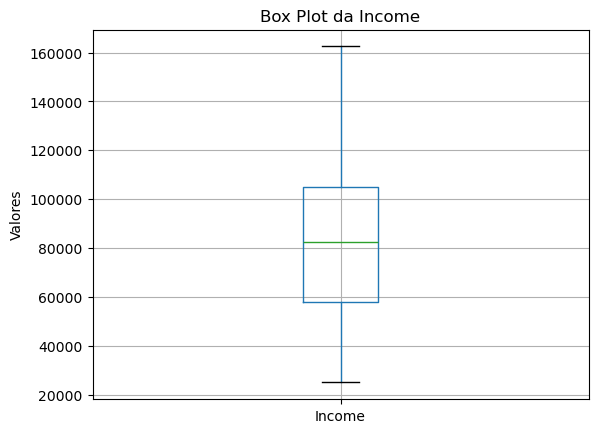

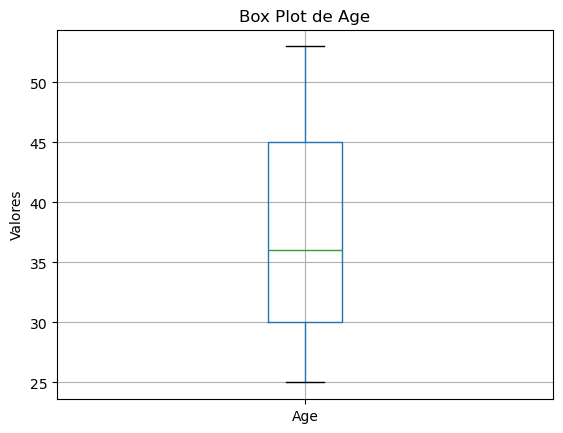

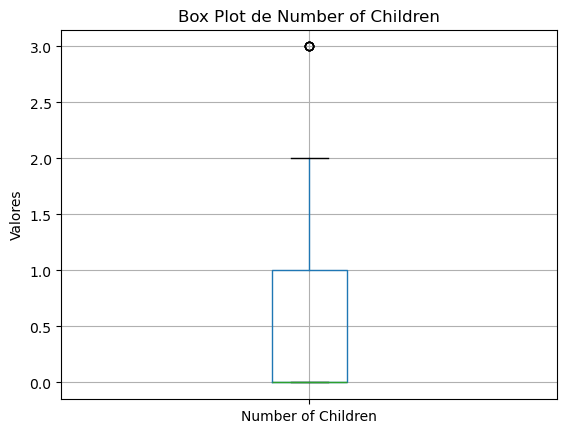

In [7]:
#seu código aqui 
def br(x):
    return f'{x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')

pd.options.display.float_format = br
df.describe()
# pelo que percebi a colunaa Income tem outliers, os valores são muito altos para o padrão.

df.boxplot(column='Income')
plt.title('Box Plot da Income')
plt.ylabel('Valores')
plt.show()

df.boxplot(column='Age')
plt.title('Box Plot de Age')
plt.ylabel('Valores')
plt.show()

df.boxplot(column='Number of Children')
plt.title('Box Plot de Number of Children')
plt.ylabel('Valores')
plt.show()

# O único dado que realmente trouxe outliers foi o número de crianças, os demais de acordo com os gráficos, estão dentro do esperado, com variações plausíveis

**B) Agora realize a análise univariada para as variaveis categóricas, plote gráficos para entender a distribuição das categorias e tente retirar insights de cada gráfico.**

C:\Users\juhan\AppData\Local\Temp\ipykernel_11532\1785758495.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(i, v + 1, f'{porcentagem[i]:.2f}%', ha='center')


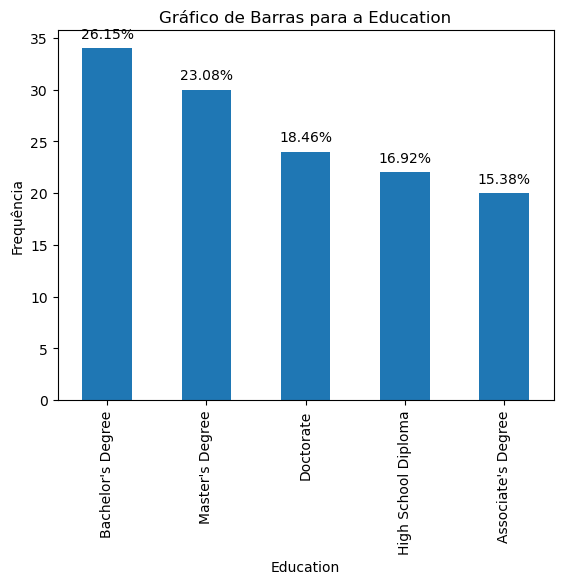

C:\Users\juhan\AppData\Local\Temp\ipykernel_11532\1785758495.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(i, v + 1, f'{porcentagem[i]:.2f}%', ha='center')


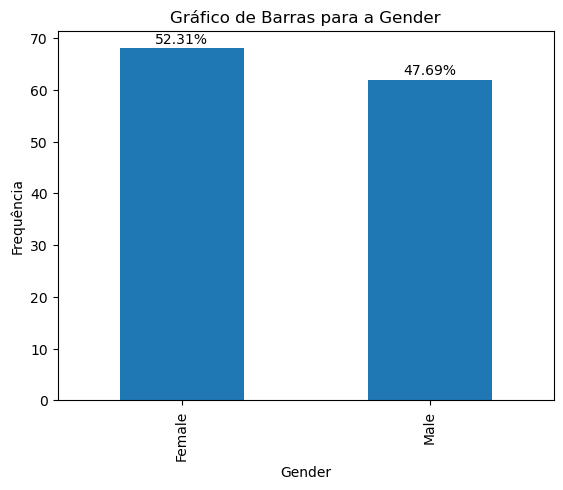

C:\Users\juhan\AppData\Local\Temp\ipykernel_11532\1785758495.py:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(i, v + 1, f'{porcentagem[i]:.2f}%', ha='center')


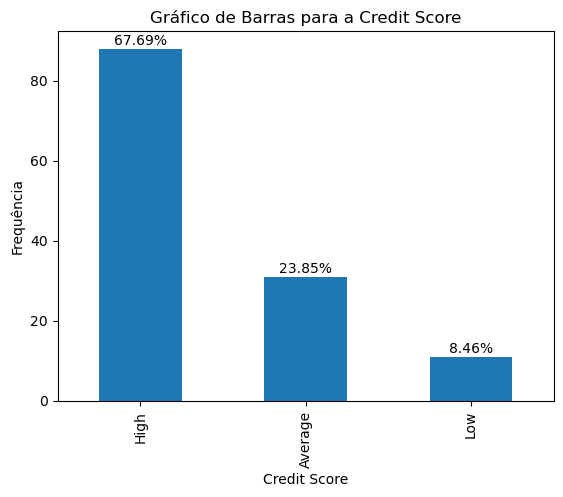

In [8]:
#seu código aqui

# Calculando as porcentagens
contagem = df['Education'].value_counts()
porcentagem = (contagem / contagem.sum()) * 100


ax = contagem.plot(kind='bar')

# Adicionando pora procentagem nas barras
for i, v in enumerate(contagem):
    ax.text(i, v + 1, f'{porcentagem[i]:.2f}%', ha='center')
plt.title('Gráfico de Barras para a Education')
plt.xlabel('Education')
plt.ylabel('Frequência')

plt.show()

# Calculando as porcentagens
contagem = df['Gender'].value_counts()
porcentagem = (contagem / contagem.sum()) * 100


ax = contagem.plot(kind='bar')


for i, v in enumerate(contagem):
    ax.text(i, v + 1, f'{porcentagem[i]:.2f}%', ha='center')
plt.title('Gráfico de Barras para a Gender')
plt.xlabel('Gender')
plt.ylabel('Frequência')

plt.show()

# Calculando as porcentagens
contagem = df['Credit Score'].value_counts()
porcentagem = (contagem / contagem.sum()) * 100


ax = contagem.plot(kind='bar')

# Adicionando pora procentagem nas barras
for i, v in enumerate(contagem):
    ax.text(i, v + 1, f'{porcentagem[i]:.2f}%', ha='center')
plt.title('Gráfico de Barras para a Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Frequência')

plt.show()

# 1) vemos que a maior parte da graduação é de bacharelado, seguido de mestrado e doutorado, o que mostra uma base com formação elevada
# 2) Temos mais mulheres do que homens no gráfico, isso pode indicar que mulheres tem mais formação do que homens, será algo que vou verificar posteriormente
# 3) Estamos diante de uma base com um credit score elevadissimo

**C) Você encontrou alguma coluna com outliers?
Se sim realize o tratamento desses casos.**

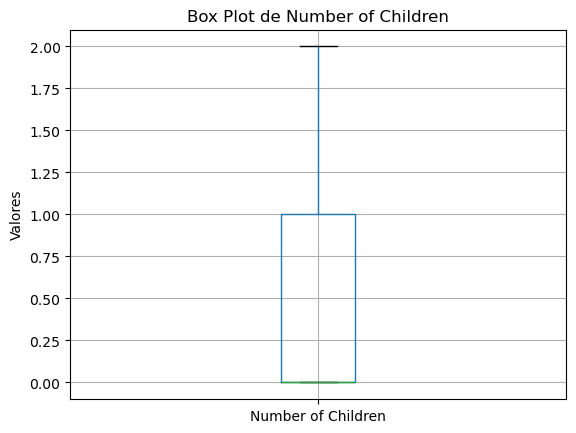

In [9]:
# Calculando limites pelo IQR
Q1 = df['Number of Children'].quantile(0.25)
Q3 = df['Number of Children'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Calculando a moda sem os outliers
df_sem_outliers = df[(df['Number of Children'] >= limite_inferior) & (df['Number of Children'] <= limite_superior)]
moda_sem_outliers = df_sem_outliers['Number of Children'].mode()[0]

# Função para substituir outliers pela moda
def substituir_outlier(x):
    if x < limite_inferior or x > limite_superior:
        return moda_sem_outliers
    else:
        return x

# Aplicando a função
df['Number of Children'] = df['Number of Children'].apply(substituir_outlier)

# Exibir boxplot final
df.boxplot(column='Number of Children')
plt.title('Box Plot de Number of Children')
plt.ylabel('Valores')
plt.show()

**D) Realize a análise Bivariada.
Tente responder as seguintes perguntas com gráficos seguidos de insights:**



*   Existe relação entre a idade e o status civil?
*   Qual a relação entre o score de crédito e o nível de escolaridade?
*  O salário parece influenciar na idade?
* O salário parece influenciar no Score de Crédito?
* Clientes com casa própria tendem a ter um score mais alto?



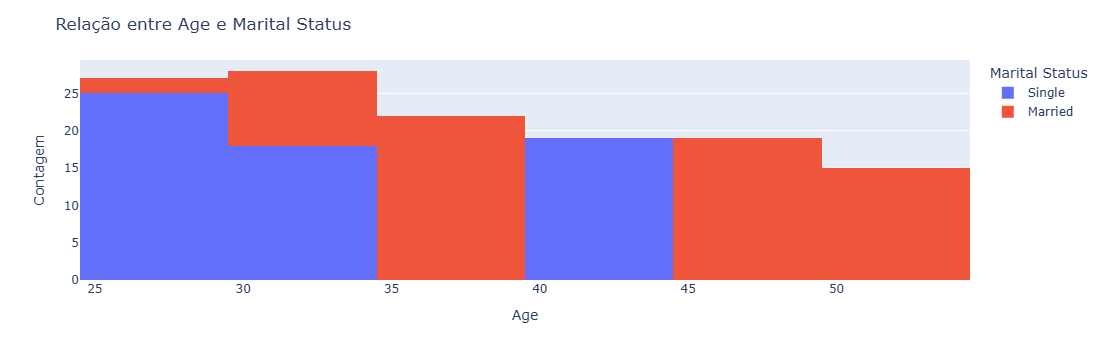

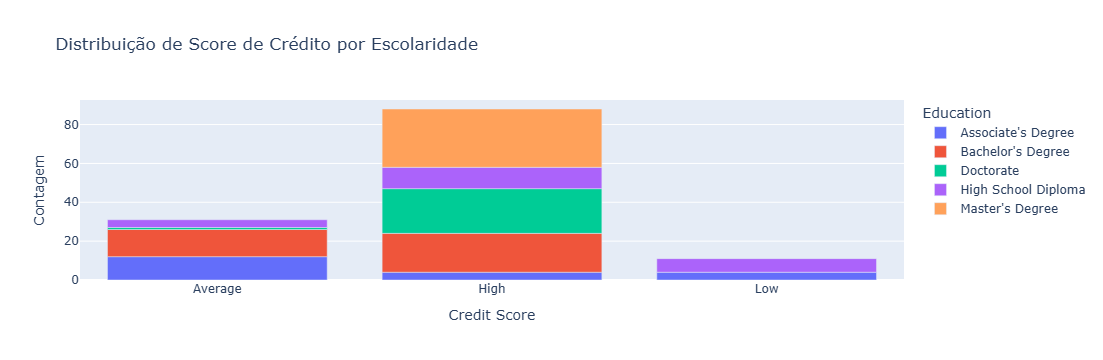

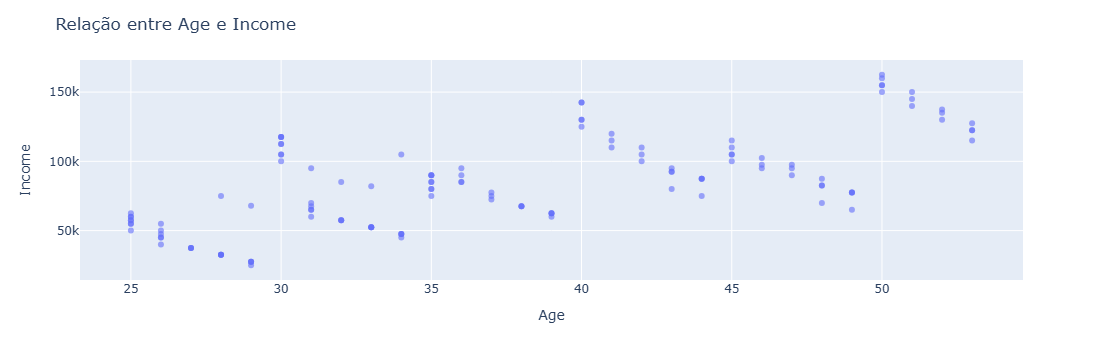

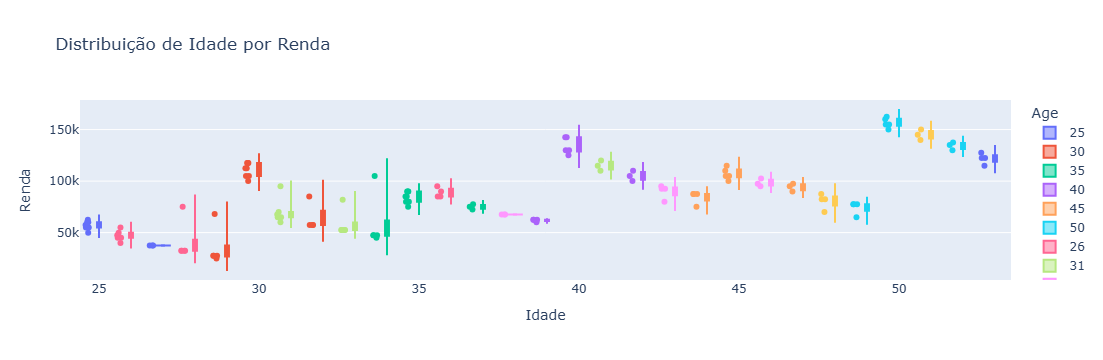

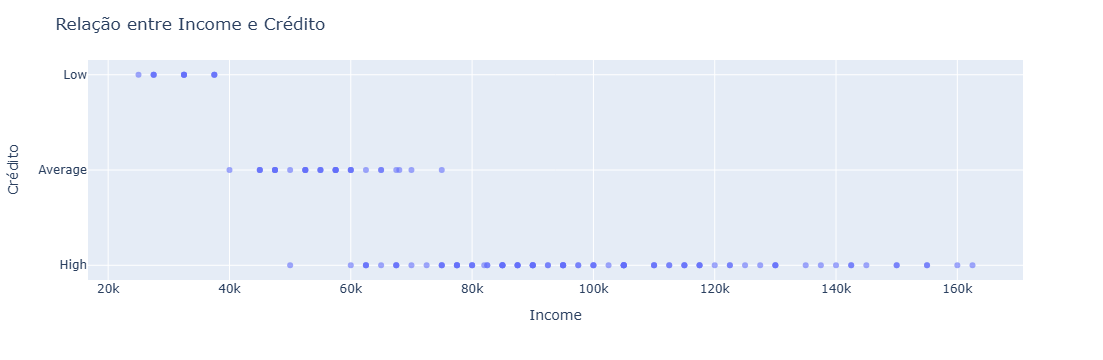

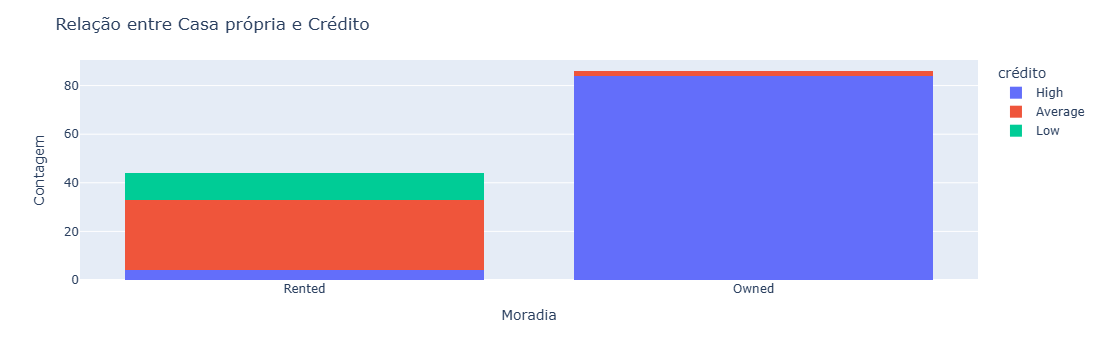

In [22]:
#seu código aqui

# Relação entre Age e Marital_Status_cod
fig = px.histogram(df, x='Age', color='Marital Status', barmode='stack')

# Layout
fig.update_layout(title='Relação entre Age e Marital Status',
                  xaxis_title='Age',
                  yaxis_title='Contagem',
                  legend_title='Marital Status')
fig.show()

# Score e nível de escolaridade
proporcao_contratos = df.groupby(['Credit Score', 'Education']).size().reset_index(name='Contagem')

fig = px.bar(proporcao_contratos, x='Credit Score', y='Contagem', color='Education',
             title='Distribuição de Score de Crédito por Escolaridade')

fig.show()

# Renda e idade

fig = px.scatter(df, x='Age', y='Income', opacity=0.6)

fig.update_layout(

  title='Relação entre Age e Income',

  xaxis_title='Age',

  yaxis_title='Income'

)

fig.show()

fig = px.violin(
    df,
    x='Age',
    y='Income',
    color='Age', 
    box=True, 
    points='all', 
    title='Distribuição de Idade por Renda'
)

fig.update_layout(
    xaxis_title='Idade',
    yaxis_title='Renda'
)

fig.show()

#salário e Score

fig = px.scatter(df, x='Income', y='Credit Score', opacity=0.6)

fig.update_layout(

  title='Relação entre Income e Crédito',

  xaxis_title='Income',

  yaxis_title='Crédito'
    )

fig.show()

#casa própria score

fig = px.histogram(df, x='Home Ownership', color='Credit Score', barmode='stack')

# Layout
fig.update_layout(title='Relação entre Casa própria e Crédito',
                  xaxis_title='Moradia',
                  yaxis_title='Contagem',
                  legend_title='crédito')
fig.show()


# Sim a partir dos 35 anos vemos que existe uma tendência ao casamento, porem dos 40 aos 44 não temos casados (me pergunto se isso ocorreu por causa do dropna de antes) e volta a ter casados a partir dos 45
# Quem tem formação elevada tende a ter average para high score, não vemos nínguem com low tendo um diploma a partir do bacharelado.
# Sim, quanto mais idade (o que acarreta experiência ou senioridade) a renda aumenta progressivamente.
# Sim, quanto maior o salário maior o score.
# Sim, quem tem casa própria tem score mais alto

**E) Que outras perguntas te parecem fazer sentido explorarmos a resposta para conhecermos mais nossa base de dados e o comportamento dos clientes?**

 Elabore mais 3 perguntas e responda utilizando gráficos + insights.

In [11]:
# seu código aqui
# Perguntas
# 1) Quem tende a ter os melhores titulos de educação, homens ou mulheres?
# 2) Mulheres com titulo de educação maior recebem mais que homens com titulo menor?
# 3) Mesmo com menor educação os homens tendem a ter score mais alto?
df.head()

# 1)
fig = px.histogram(df, x='Gender', color='Education', barmode='stack')

# Layout
fig.update_layout(title='Relação entre Gênero e educação',
                  xaxis_title='Gender',
                  yaxis_title='Contagem',
                  legend_title='Education')
fig.show()

#2) Gênero e Score
fig = px.scatter(df, x='Gender', y='Income', opacity=0.6)

fig.update_layout(

  title='Relação entre Gênero e Renda',

  xaxis_title='gênero',

  yaxis_title='Renda'

)

fig.show()

#3) 
fig = px.histogram(df, x='Gender', color='Credit Score', barmode='stack')

# Layout
fig.update_layout(title='Relação entre Gênero e Score',
                  xaxis_title='Genêro',
                  yaxis_title='Contagem',
                  legend_title='Score')

# 1) Existem mais mulheres na base, porém percebemos que elas detém a maior parte do bacharelado e do doutorado enquanto os homens detém o Mestrado e high school (vale observar que esse deve ser o "diploma atual", pois uma pessoa com doutorado teve que passar pelo high school, masters etc)
# 2) vemos que mesmo assim os homens conseguem maiores salários, mesmo com a menor quantidade de diplomas, proporcionalmente falando e a diferença de salário é gritante
# 3) sim, tanto é que não tem nenhum homem com "low score"

# Etapa 3: Relize os passos que vimos no módulo 17, de Correlação, Balanceamento, atributos categóricos e divisão base treino e teste.

**A) Vamos começar pela análise de correlação, plote da forma que achar melhor a análise de correlação, seja pela tabela ou pelo gráfico da matriz.**

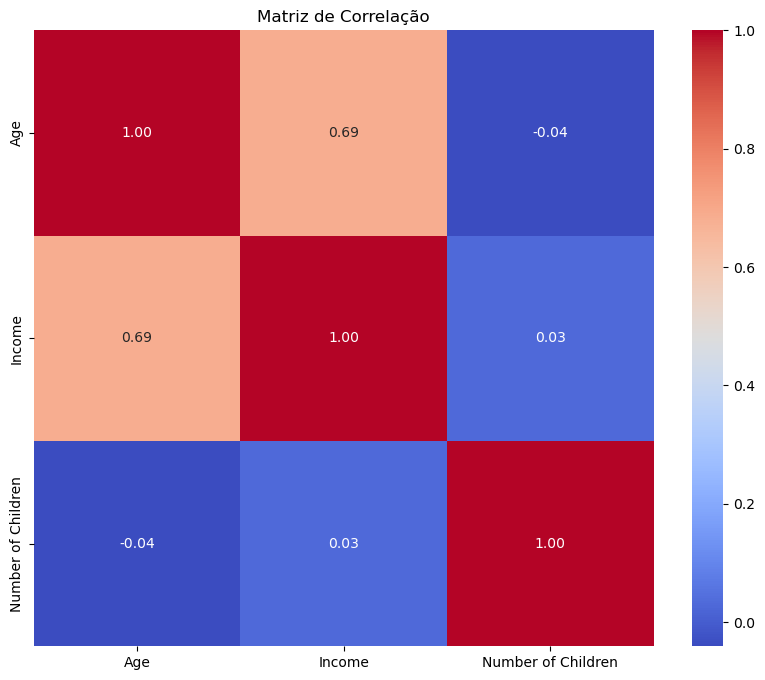

In [12]:
#seu código aqui
correlation_matrix = df.select_dtypes(include=['number']).corr()

# Plotar o mapa de calor da matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

**B) Você encontrou variáveis que tem uma média ou alta correlação? Se sim, quais? Te parece fazer sentido essas variáveis terem alta correlação? Justifique.**

In [13]:
# sua justificativa aqui

# Renda e idade são as 2 matrizes que tem correlação alta, faz sentido pois diria que a medida que vamos obtendo experiência em nossos campos a tendência é conseguir aumento de salário

**C) Temos muitos atributos categóricos nessa base, não? Vamos realizar a o tratamento desses atributos utilizando Label Encoder ou one hot. Após, exclua as colunas categóricas.**

In [14]:
from sklearn.preprocessing import LabelEncoder

# Criando uma instância do Label Encoder
label_encoder = LabelEncoder()


# Separar target
X = df.drop('Credit Score', axis=1)
y = df['Credit Score']

# Encoding apenas nas features
X = pd.get_dummies(X, columns=['Education'], drop_first=True)

# Label encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
X['Genero_encoded'] = le.fit_transform(X['Gender'])
X['Home_Ownership'] = le.fit_transform(X['Home Ownership'])
X['Marital_encoded'] = le.fit_transform(X['Marital Status'])

# Drop colunas originais
X = X.drop(['Gender', 'Home Ownership', 'Marital Status'], axis=1)

**D) Vamos plotar novamente a correlação, agora observando com as variáveis categóricas. Identifique se temos novas variáveis com forte correlação.**

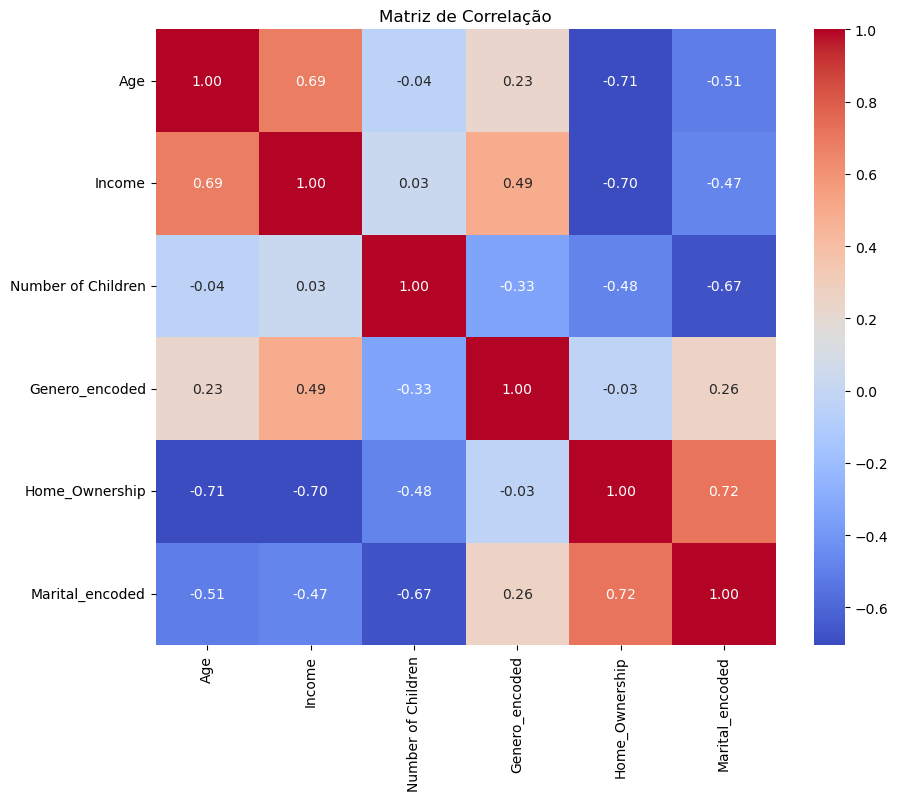

In [15]:
#seu código aqui
correlation_matrix = X.select_dtypes(include=['number']).corr()

# Plotar o mapa de calor da matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

**F) Faça a separação da base em treino e teste e verifique utilizando shape:**

In [16]:
#seu código aqui
from sklearn.model_selection import train_test_split

# Seu código abaixo:
# Divisão treino e teste (70% treino / 30% teste)
X_train, X_test, y_train, y_test = train_test_split(
 X, y,
 test_size=0.3,
 random_state=42
)

**G) É hora de verificar se nossa coluna de Score de crédito está balanceada, verifique através de um gráfico e traga sua opinião acerca do balanceamento.**

In [17]:
#seu código aqui

churn_counts = df['Credit Score'].value_counts()
plt.figure(figsize=(8, 6))
churn_counts.plot(kind='bar', color=['blue', 'orange'])
#plt.show()
print((df['Credit Score'].value_counts(normalize=True) * 100))

Credit Score
High      67,69
Average   23,85
Low        8,46
Name: proportion, dtype: float64


**H) Vamos realizar o balancecamento dos dados da coluna de credit score.**
Se lembre que realizazmos apenas para a base de treino.

In [18]:
#seu código aqui

from imblearn.over_sampling import SMOTE

# Criar uma instância do SMOTE
smote = SMOTE(random_state=42)

# Aplicar o SMOTE aos dados de treinamento (X_train, y_train)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Verificar a distribuição das classes após o balanceamento
print("Distribuição das classes após o balanceamento:")
print(y_train_balanced.value_counts())

Distribuição das classes após o balanceamento:
Credit Score
Average    62
High       62
Low        62
Name: count, dtype: int64


C:\Users\juhan\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning:

Could not find the number of physical cores for the following reason:
[WinError 2] O sistema não pode encontrar o arquivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.

  File "C:\Users\juhan\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\juhan\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\juhan\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^